# 03. Feature Engineering

This notebook focuses on creating and engineering features for the charging station prediction model.

## Objectives:
1. Create target variable for charging station suitability
2. Engineer features for machine learning models
3. Handle categorical variables
4. Create geographic and demographic features
5. Prepare data for model training


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_ev_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Dataset shape: (250659, 20)
Columns: ['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract', 'Vehicle Age', 'Longitude', 'Latitude']


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,Vehicle Age,Longitude,Latitude
0,5YJSA1E65N,Yakima,Granger,Wa,98932.0,2022,Tesla,Model S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,215.0,69900.0,15.0,187279214,POINT (-120.1871 46.33949),PACIFICORP,5.307700e+10,2,-120.18710,46.33949
1,KNDC3DLC5N,Yakima,Yakima,Wa,98902.0,2022,Kia,Ev6,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,215.0,NaN,15.0,210098241,POINT (-120.52041 46.59751),PACIFICORP,5.307700e+10,2,-120.52041,46.59751
2,5YJYGDEEXL,Snohomish,Everett,Wa,98208.0,2020,Tesla,Model Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,NaN,44.0,121781950,POINT (-122.18637 47.89251),PUGET SOUND ENERGY INC,5.306104e+10,4,-122.18637,47.89251
3,3C3CFFGE1G,Yakima,Yakima,Wa,98908.0,2016,Fiat,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,NaN,14.0,180778377,POINT (-120.60199 46.59817),PACIFICORP,5.307700e+10,8,-120.60199,46.59817
4,KNDCC3LD5K,Kitsap,Bremerton,Wa,98312.0,2019,Kia,Niro,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,NaN,26.0,2581225,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303508e+10,5,-122.65223,47.57192


In [3]:
# 1. Create Target Variable - Charging Station Suitability Score
print("Creating Target Variable...")

# Group by city to create city-level features
city_features = df.groupby(['County', 'City']).agg({
    'VIN (1-10)': 'count',  # EV count
    'Electric Range': ['mean', 'std', 'min', 'max'],  # Range statistics
    'Base MSRP': ['mean', 'std', 'min', 'max'],  # Price statistics
    'Model Year': ['mean', 'min', 'max'],  # Age statistics
    'Longitude': 'mean',  # Geographic center
    'Latitude': 'mean',
    'Vehicle Age': 'mean'  # Average vehicle age
}).round(4)

# Flatten column names
city_features.columns = ['_'.join(col).strip() for col in city_features.columns]
city_features = city_features.reset_index()

# Create target variable - Charging Station Suitability Score
# Factors: EV density, range diversity, affordability, vehicle age
city_features['EV_Count'] = city_features['VIN (1-10)_count']
city_features['Avg_Range'] = city_features['Electric Range_mean']
city_features['Range_Std'] = city_features['Electric Range_std'].fillna(0)
city_features['Avg_MSRP'] = city_features['Base MSRP_mean']
city_features['Avg_Age'] = city_features['Vehicle Age_mean']

# Calculate charging station suitability score
city_features['Charging_Score'] = (
    city_features['EV_Count'] * 0.4 +  # Primary: EV count
    (city_features['Avg_Range'] / 100) * 0.2 +  # Secondary: average range
    (city_features['Range_Std'] / 50) * 0.1 +  # Tertiary: range diversity
    (100000 / city_features['Avg_MSRP']) * 0.2 +  # Tertiary: affordability
    (10 - city_features['Avg_Age']) * 0.1  # Tertiary: newer vehicles
).round(2)

print(f"Created city-level dataset with {len(city_features)} cities")
print(f"Charging score range: {city_features['Charging_Score'].min():.2f} - {city_features['Charging_Score'].max():.2f}")

city_features.head()


Creating Target Variable...
Created city-level dataset with 895 cities
Charging score range: 1.04 - 15908.79


,County,City,VIN (1-10)_count,Electric Range_mean,Electric Range_std,Electric Range_min,Electric Range_max,Base MSRP_mean,Base MSRP_std,Base MSRP_min,...,Model Year_max,Longitude_mean,Latitude_mean,Vehicle Age_mean,EV_Count,Avg_Range,Range_Std,Avg_MSRP,Avg_Age,Charging_Score
0,Ada,Boise,2,215.0000,0.0000,215.0,215.0,NaN,NaN,NaN,...,2023,-116.1734,43.5804,1.5000,2,215.0000,0.0000,NaN,1.5000,NaN
1,Adams,Benge,1,32.0000,NaN,32.0,32.0,39995.0,NaN,39995.0,...,2025,-118.1026,46.9090,-1.0000,1,32.0000,0.0000,39995.0,-1.0000,2.06
2,Adams,Hatton,1,266.0000,NaN,266.0,266.0,NaN,NaN,NaN,...,2020,-119.1742,46.8262,4.0000,1,266.0000,0.0000,NaN,4.0000,NaN
3,Adams,Lind,3,215.0000,0.0000,215.0,215.0,NaN,NaN,NaN,...,2024,-118.6157,46.9714,1.0000,3,215.0000,0.0000,NaN,1.0000,NaN
4,Adams,Othello,63,174.3651,89.1408,18.0,322.0,59712.5,12569.83,44100.0,...,2025,-119.1742,46.8262,2.7778,63,174.3651,89.1408,59712.5,2.7778,26.78


In [4]:
# 2. Create Additional Features
print("Creating Additional Features...")

# EV Type distribution by city
ev_type_by_city = df.groupby(['County', 'City', 'Electric Vehicle Type']).size().unstack(fill_value=0)
ev_type_by_city['Total_EVs'] = ev_type_by_city.sum(axis=1)
ev_type_by_city['BEV_Ratio'] = ev_type_by_city.get('Battery Electric Vehicle (BEV)', 0) / ev_type_by_city['Total_EVs']
ev_type_by_city['PHEV_Ratio'] = ev_type_by_city.get('Plug-in Hybrid Electric Vehicle (PHEV)', 0) / ev_type_by_city['Total_EVs']

# Make distribution by city
make_by_city = df.groupby(['County', 'City', 'Make']).size().unstack(fill_value=0)
make_by_city['Make_Diversity'] = (make_by_city > 0).sum(axis=1)  # Number of different makes

# Merge with city_features
city_features = city_features.merge(ev_type_by_city[['BEV_Ratio', 'PHEV_Ratio']], 
                                   left_on=['County', 'City'], 
                                   right_index=True, 
                                   how='left')

city_features = city_features.merge(make_by_city[['Make_Diversity']], 
                                   left_on=['County', 'City'], 
                                   right_index=True, 
                                   how='left')

# Fill missing values
city_features['BEV_Ratio'] = city_features['BEV_Ratio'].fillna(0)
city_features['PHEV_Ratio'] = city_features['PHEV_Ratio'].fillna(0)
city_features['Make_Diversity'] = city_features['Make_Diversity'].fillna(1)

print("✓ Added EV type ratios and make diversity features")

# Create geographic features
city_features['Distance_From_Seattle'] = np.sqrt(
    (city_features['Latitude_mean'] - 47.6062)**2 + 
    (city_features['Longitude_mean'] - (-122.3321))**2
)

city_features['Distance_From_Spokane'] = np.sqrt(
    (city_features['Latitude_mean'] - 47.6588)**2 + 
    (city_features['Longitude_mean'] - (-117.4260))**2
)

print("✓ Added geographic distance features")

# Create categorical features
city_features['County_Encoded'] = LabelEncoder().fit_transform(city_features['County'])

# Create EV density categories
city_features['EV_Density_Category'] = pd.cut(
    city_features['EV_Count'], 
    bins=[0, 10, 50, 100, float('inf')], 
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("✓ Added categorical features")

print(f"Final feature set shape: {city_features.shape}")
print(f"Features: {list(city_features.columns)}")


Creating Additional Features...
✓ Added EV type ratios and make diversity features
✓ Added geographic distance features
✓ Added categorical features
Final feature set shape: (895, 30)
Features: ['County', 'City', 'VIN (1-10)_count', 'Electric Range_mean', 'Electric Range_std', 'Electric Range_min', 'Electric Range_max', 'Base MSRP_mean', 'Base MSRP_std', 'Base MSRP_min', 'Base MSRP_max', 'Model Year_mean', 'Model Year_min', 'Model Year_max', 'Longitude_mean', 'Latitude_mean', 'Vehicle Age_mean', 'EV_Count', 'Avg_Range', 'Range_Std', 'Avg_MSRP', 'Avg_Age', 'Charging_Score', 'BEV_Ratio', 'PHEV_Ratio', 'Make_Diversity', 'Distance_From_Seattle', 'Distance_From_Spokane', 'County_Encoded', 'EV_Density_Category']


In [5]:
# 3. Prepare Data for Machine Learning
print("Preparing Data for Machine Learning...")

# Select features for modeling
feature_columns = [
    'EV_Count', 'Avg_Range', 'Range_Std', 'Avg_MSRP', 'Avg_Age',
    'BEV_Ratio', 'PHEV_Ratio', 'Make_Diversity',
    'Distance_From_Seattle', 'Distance_From_Spokane',
    'County_Encoded'
]

# Create feature matrix and target
X = city_features[feature_columns].copy()
y = city_features['Charging_Score'].copy()

# Handle any remaining missing values
X = X.fillna(X.median())

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Data prepared for machine learning")

# Display feature importance (correlation with target)
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Correlation': [X[col].corr(y) for col in feature_columns]
}).sort_values('Correlation', key=abs, ascending=False)

print("\nFeature Correlation with Charging Score:")
print(feature_importance)


Preparing Data for Machine Learning...
Feature matrix shape: (895, 11)
Target shape: (895,)
Training set: (716, 11)
Test set: (179, 11)
✓ Data prepared for machine learning

Feature Correlation with Charging Score:
                  Feature  Correlation
0                EV_Count     1.000000
7          Make_Diversity     0.411811
5               BEV_Ratio     0.110447
6              PHEV_Ratio    -0.110447
8   Distance_From_Seattle    -0.109018
4                 Avg_Age    -0.102627
1               Avg_Range     0.094560
9   Distance_From_Spokane    -0.068516
10         County_Encoded    -0.033052
2               Range_Std     0.009821
3                Avg_MSRP     0.008059


Creating Feature Visualizations...


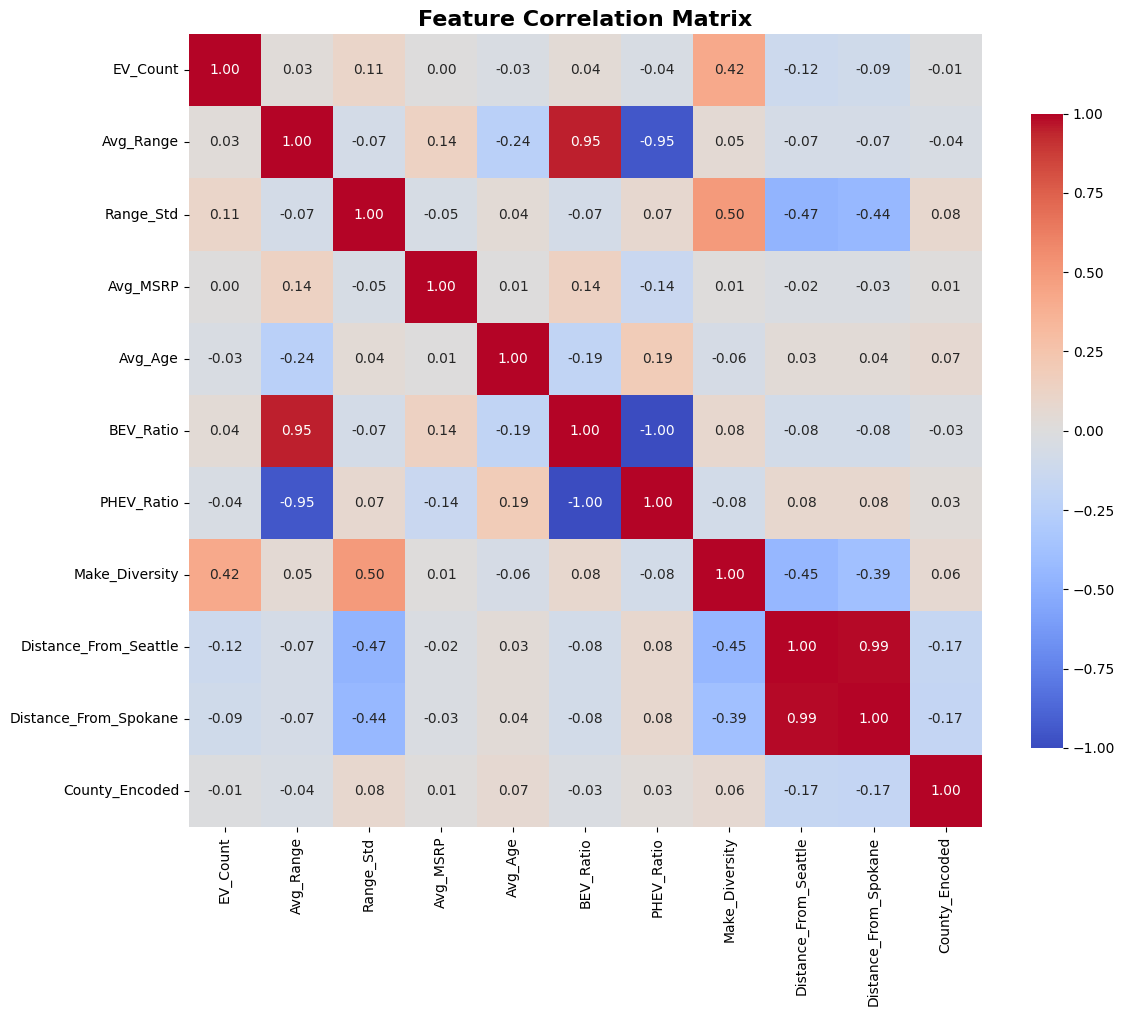

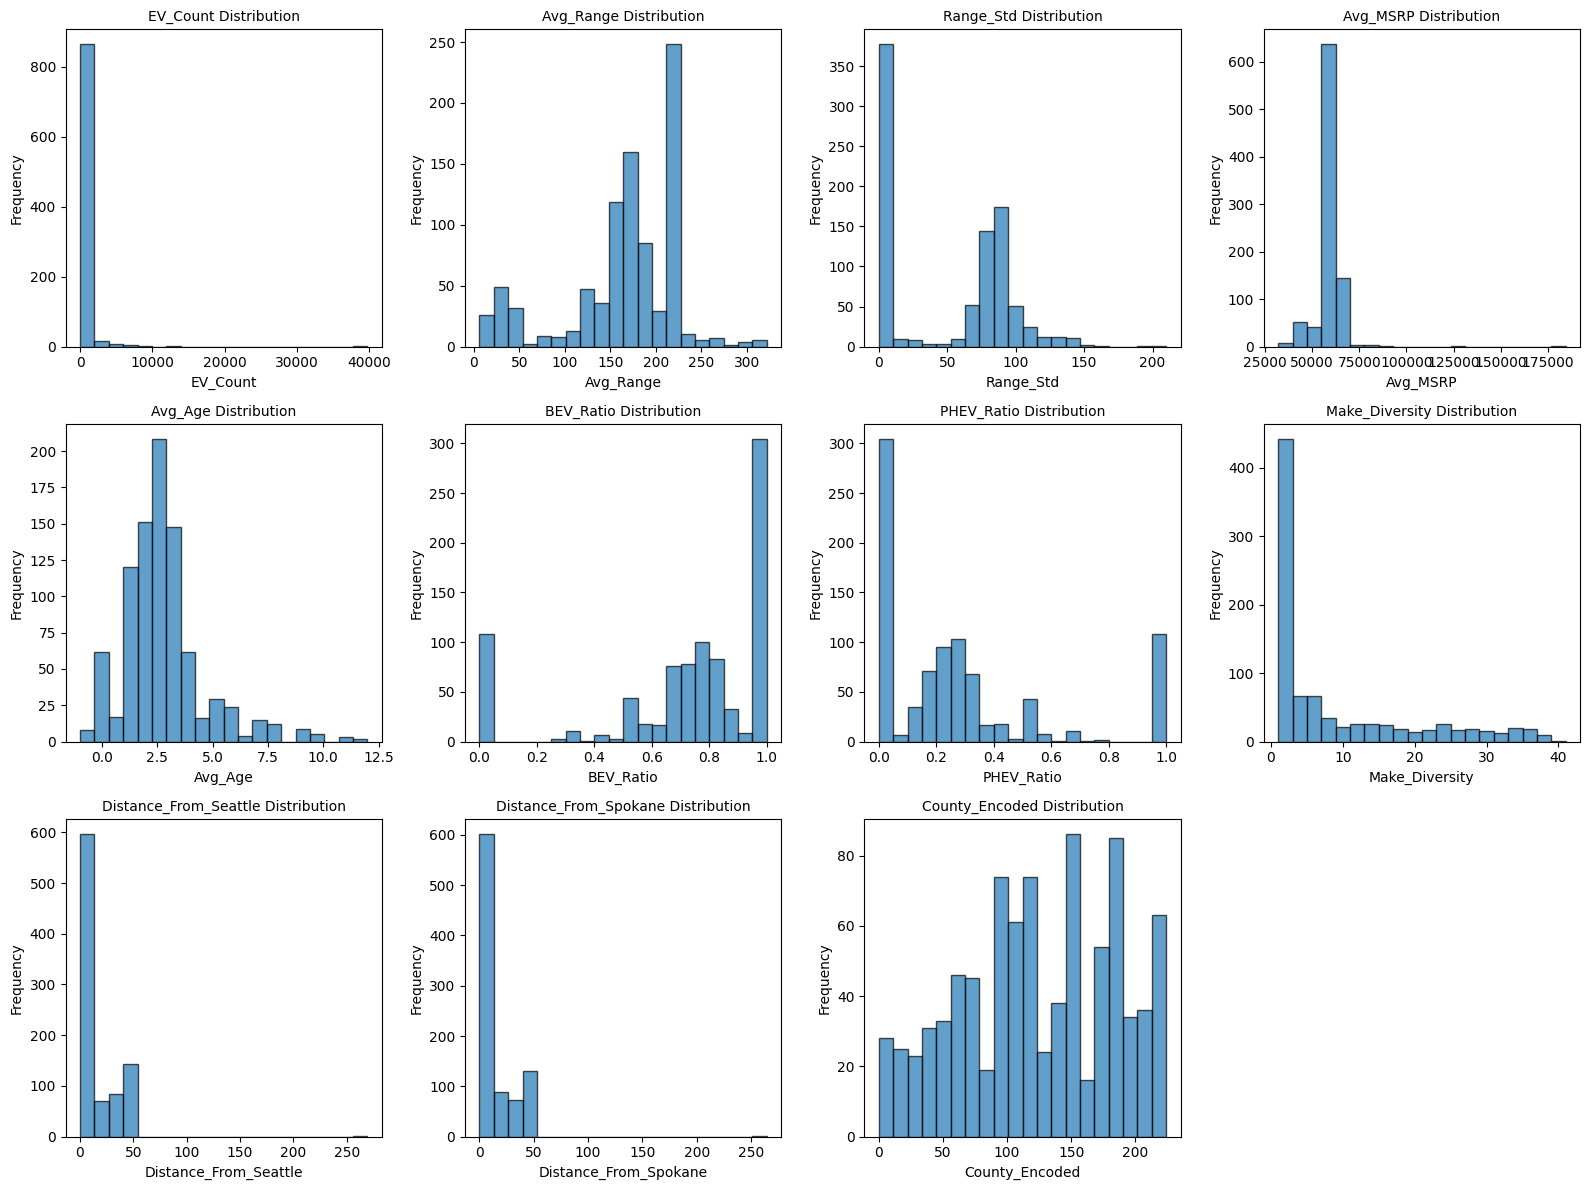

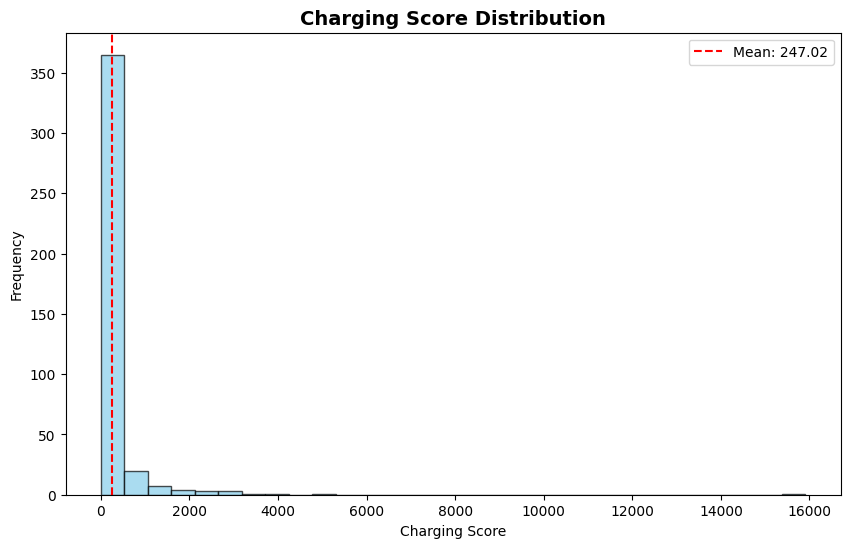

✓ Feature visualizations created


In [6]:
# 4. Visualize Feature Relationships
print("Creating Feature Visualizations...")

# Create correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature distribution plots
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(feature_columns):
    if i < len(axes):
        axes[i].hist(X[col], bins=20, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'{col} Distribution', fontsize=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Remove empty subplots
for i in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Target variable distribution
plt.figure(figsize=(10, 6))
plt.hist(y, bins=30, alpha=0.7, edgecolor='black', color='skyblue')
plt.title('Charging Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Charging Score')
plt.ylabel('Frequency')
plt.axvline(y.mean(), color='red', linestyle='--', 
            label=f'Mean: {y.mean():.2f}')
plt.legend()
plt.show()

print("✓ Feature visualizations created")


In [7]:
# 5. Save Processed Data
print("Saving Processed Data...")

# Save city features with all engineered features
city_features.to_csv('../data/processed/city_features_engineered.csv', index=False)
print("✓ City features saved")

# Save training and test sets
np.save('../data/processed/X_train.npy', X_train_scaled)
np.save('../data/processed/X_test.npy', X_test_scaled)
np.save('../data/processed/y_train.npy', y_train.values)
np.save('../data/processed/y_test.npy', y_test.values)
print("✓ Training and test sets saved")

# Save feature names and scaler
import joblib
joblib.dump(feature_columns, '../data/processed/feature_columns.pkl')
joblib.dump(scaler, '../data/processed/scaler.pkl')
print("✓ Feature columns and scaler saved")

# Save feature importance
feature_importance.to_csv('../data/processed/feature_importance.csv', index=False)
print("✓ Feature importance saved")

# Create summary
summary = {
    'total_cities': len(city_features),
    'features_count': len(feature_columns),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'target_range': [float(y.min()), float(y.max())],
    'target_mean': float(y.mean()),
    'target_std': float(y.std())
}

import json
with open('../data/processed/feature_engineering_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Feature engineering summary saved")

print("\nFeature Engineering Summary:")
print("=" * 40)
for key, value in summary.items():
    print(f"{key.replace('_', ' ').title()}: {value}")

print("\nFeature Engineering completed successfully!")
print("Data is now ready for model training.")


Saving Processed Data...
✓ City features saved
✓ Training and test sets saved
✓ Feature columns and scaler saved
✓ Feature importance saved
✓ Feature engineering summary saved

Feature Engineering Summary:
Total Cities: 895
Features Count: 11
Training Samples: 716
Test Samples: 179
Target Range: [1.04, 15908.79]
Target Mean: 247.01972906403944
Target Std: 942.5690926784974

Feature Engineering completed successfully!
Data is now ready for model training.
